<h1>Вторая практическая, поиск ассоциативных правил</h1>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from mlxtend.frequent_patterns import apriori, association_rules

In [68]:
df = pd.read_excel("Online Retail.xlsx")

C:\Users\ivans\AppData\Local\Programs\Python\Python312\Lib\site-packages\openpyxl\packaging\core.py:99: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  now = datetime.datetime.utcnow()
C:\Users\ivans\AppData\Local\Programs\Python\Python312\Lib\site-packages\openpyxl\packaging\core.py:99: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  now = datetime.datetime.utcnow()


<h2>Предобработка</h2>

In [3]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
orig_df = df

возьмем Францию

In [5]:
df = df[df['Country'] == "France"]

In [6]:
df = df[df['Description']!=np.nan]
df = df[df['Description']!=""]
df = df[df['Description']!=" "]
df = df[df['InvoiceNo']!=np.nan]
df = df[df['InvoiceNo']!=""]
df = df[df['InvoiceNo']!=" "]


In [7]:
df = df[~df['InvoiceNo'].str.endswith('C', na=False)] 

In [8]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [9]:
# Удаляем дубликаты (один товар в одной транзакции)
df = df.drop_duplicates(subset=['InvoiceNo', 'StockCode'])
enc_df = df[['InvoiceNo', 'StockCode']]
# Применяем one-hot encoding
one_hot_df = pd.get_dummies(enc_df, columns=['StockCode'], prefix='', prefix_sep='')
# Суммируем по InvoiceNo, чтобы объединить товары в одну строку для каждой транзакции
one_hot_df = one_hot_df.groupby('InvoiceNo').sum().reset_index()
for_conc = df[['Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']]
extra_df = pd.concat([one_hot_df, for_conc], axis=1)

<h2>Анализ</h2>

In [10]:
NO_InvoiceNo = one_hot_df.drop('InvoiceNo', axis=1)

In [33]:
# Шаг 1: Частые наборы
frequent_itemsets = apriori(NO_InvoiceNo, min_support=0.1, use_colnames=True)


C:\Users\ivans\AppData\Local\Programs\Python\Python312\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


In [34]:
print(frequent_itemsets)


     support        itemsets
0   0.132321         (20725)
1   0.101952         (20726)
2   0.119306         (20750)
3   0.112798         (21080)
4   0.117137         (21086)
5   0.108460         (21094)
6   0.104121         (21559)
7   0.156182         (21731)
8   0.138829         (22326)
9   0.123644         (22352)
10  0.104121         (22382)
11  0.117137         (22423)
12  0.119306         (22551)
13  0.145336         (22554)
14  0.147505         (22556)
15  0.106291         (22629)
16  0.162690         (23084)
17  0.108460         (23206)
18  0.674620          (POST)
19  0.104121   (20725, POST)
20  0.104121  (21086, 21094)
21  0.134490   (21731, POST)
22  0.125813   (22326, POST)
23  0.117137   (POST, 22554)
24  0.125813   (POST, 22556)
25  0.140998   (23084, POST)


In [35]:
from mlxtend.frequent_patterns import association_rules
rules = association_rules(frequent_itemsets,num_itemsets=len(NO_InvoiceNo), metric="confidence", min_threshold=0.7)


In [36]:
rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(20725),(POST),0.132321,0.674620,0.104121,0.786885,1.166412,1.0,0.014855,1.526781,0.164427,0.148148,0.345027,0.470613
1,(21086),(21094),0.117137,0.108460,0.104121,0.888889,8.195556,1.0,0.091417,8.023861,0.994472,0.857143,0.875372,0.924444
2,(21094),(21086),0.108460,0.117137,0.104121,0.960000,8.195556,1.0,0.091417,22.071584,0.984793,0.857143,0.954693,0.924444
3,(21731),(POST),0.156182,0.674620,0.134490,0.861111,1.276438,1.0,0.029127,2.342733,0.256655,0.193146,0.573148,0.530234
4,(22326),(POST),0.138829,0.674620,0.125813,0.906250,1.343348,1.0,0.032157,3.470716,0.296795,0.182965,0.711875,0.546373
5,(22554),(POST),0.145336,0.674620,0.117137,0.805970,1.194702,1.0,0.019090,1.676956,0.190684,0.166667,0.403682,0.489802
6,(22556),(POST),0.147505,0.674620,0.125813,0.852941,1.264328,1.0,0.026303,2.212581,0.245240,0.180685,0.548039,0.519718
7,(23084),(POST),0.162690,0.674620,0.140998,0.866667,1.284673,1.0,0.031244,2.440347,0.264647,0.202492,0.590222,0.537835


In [62]:
len(rules)

14

Здесь можем наблюдать lift, leverage и conviction

In [57]:
lift = rules['lift']
leverage = rules['leverage']
conviction = rules['conviction']

<function matplotlib.pyplot.show(close=None, block=None)>

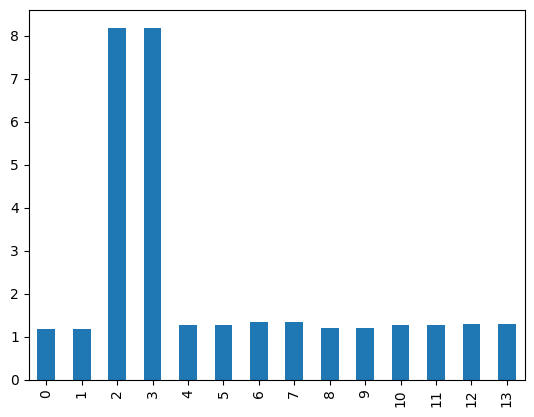

In [59]:
lift.plot(kind='bar')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

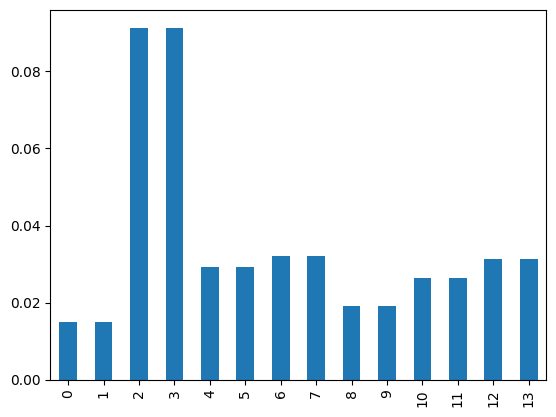

In [63]:
leverage.plot(kind='bar')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

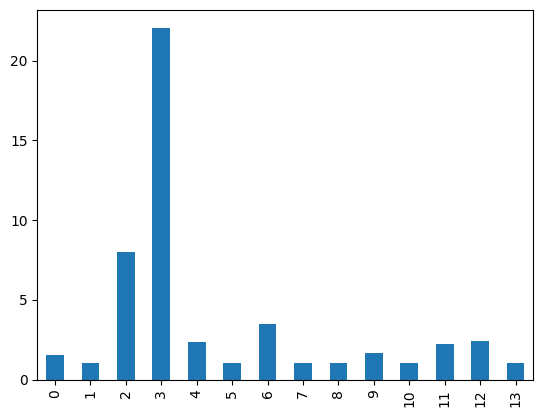

In [64]:
conviction.plot(kind='bar')
plt.show

Выполним задание: "Исследовать влияние величины пороговых значений для мер 𝑠𝑢𝑝𝑝𝑜𝑟𝑡 и 𝑐𝑜𝑛𝑓𝑖𝑑𝑒𝑛𝑐𝑒 на число генерируемых правил. Построить соответствующие график." Данное задание было выполнено методом подбора

In [47]:
support_values = [0.1,0.2, 0.3, 0.4, 0.5]
confidence_values = [0.1,0.2,0.3,0.4, 0.5, 0.6, 0.7, 0.8]

In [48]:
rules_count_support = []
rules_count_confidence = []


In [49]:
for support in support_values:
    frequent_itemsets = apriori(NO_InvoiceNo, min_support=support, use_colnames=True)
    rules = association_rules(frequent_itemsets, num_itemsets=len(NO_InvoiceNo), metric="confidence", min_threshold=0.7)
    rules_count_support.append(len(rules))

C:\Users\ivans\AppData\Local\Programs\Python\Python312\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(
C:\Users\ivans\AppData\Local\Programs\Python\Python312\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(
C:\Users\ivans\AppData\Local\Programs\Python\Python312\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(
C:\Users\ivans\AppData\Local\Programs\Python\Pyth

In [50]:
rules_count_support

[8, 0, 0, 0, 0]

In [53]:
for confidence in confidence_values:
    frequent_itemsets = apriori(NO_InvoiceNo, min_support=0.1, use_colnames=True)
    rules = association_rules(frequent_itemsets, num_itemsets=len(NO_InvoiceNo), metric="confidence", min_threshold=confidence)
    rules_count_confidence.append(len(rules))

C:\Users\ivans\AppData\Local\Programs\Python\Python312\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(
C:\Users\ivans\AppData\Local\Programs\Python\Python312\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(
C:\Users\ivans\AppData\Local\Programs\Python\Python312\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(
C:\Users\ivans\AppData\Local\Programs\Python\Pyth

In [54]:
rules_count_confidence

[14, 9, 8, 8, 8, 8, 8, 7]

Как можем заметить, наибольшее количество генерируемых правил появляется при как можно меньших параметрах min_support и min_threshold.

In [55]:
frequent_itemsets = apriori(NO_InvoiceNo, min_support=0.1, use_colnames=True)
rules = association_rules(frequent_itemsets, num_itemsets=len(NO_InvoiceNo), metric="confidence", min_threshold=0.1)

C:\Users\ivans\AppData\Local\Programs\Python\Python312\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


Далее будем работать с этими данными

<h2>Сравнение с другой страной</h2>

сравниваем с Германией

In [86]:
df = orig_df

In [73]:
df = df[df['Country'] == "Germany"]

In [74]:
df = df[df['Description']!=np.nan]
df = df[df['Description']!=""]
df = df[df['Description']!=" "]
df = df[df['InvoiceNo']!=np.nan]
df = df[df['InvoiceNo']!=""]
df = df[df['InvoiceNo']!=" "]


In [75]:
df = df[~df['InvoiceNo'].str.endswith('C', na=False)] 

In [76]:
# Удаляем дубликаты (один товар в одной транзакции)
df = df.drop_duplicates(subset=['InvoiceNo', 'StockCode'])
enc_df = df[['InvoiceNo', 'StockCode']]
# Применяем one-hot encoding
one_hot_df = pd.get_dummies(enc_df, columns=['StockCode'], prefix='', prefix_sep='')
# Суммируем по InvoiceNo, чтобы объединить товары в одну строку для каждой транзакции
one_hot_df = one_hot_df.groupby('InvoiceNo').sum().reset_index()
for_conc = df[['Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']]
extra_df = pd.concat([one_hot_df, for_conc], axis=1)

In [78]:
NO_InvoiceNo = one_hot_df.drop('InvoiceNo', axis=1)

In [79]:
frequent_itemsets = apriori(NO_InvoiceNo, min_support=0.1, use_colnames=True)
rules = association_rules(frequent_itemsets, num_itemsets=len(NO_InvoiceNo), metric="confidence", min_threshold=0.1)

C:\Users\ivans\AppData\Local\Programs\Python\Python312\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


In [80]:
rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(22326),(22328),0.197347,0.129353,0.102819,0.521008,4.027796,1.0,0.077292,1.817666,0.936550,0.459259,0.449844,0.657940
1,(22328),(22326),0.129353,0.197347,0.102819,0.794872,4.027796,1.0,0.077292,3.912935,0.863410,0.459259,0.744437,0.657940
2,(22326),(POST),0.197347,0.635158,0.170813,0.865546,1.362727,1.0,0.045466,2.713516,0.331622,0.258145,0.631474,0.567238
3,(POST),(22326),0.635158,0.197347,0.170813,0.268930,1.362727,1.0,0.045466,1.097915,0.729568,0.258145,0.089183,0.567238
4,(22328),(POST),0.129353,0.635158,0.114428,0.884615,1.392750,1.0,0.032268,3.161968,0.323892,0.176020,0.683741,0.532386
5,(POST),(22328),0.635158,0.129353,0.114428,0.180157,1.392750,1.0,0.032268,1.061967,0.772925,0.176020,0.058351,0.532386


In [81]:
len(rules)

6

In [82]:
lift = rules['lift']
leverage = rules['leverage']
conviction = rules['conviction']

<function matplotlib.pyplot.show(close=None, block=None)>

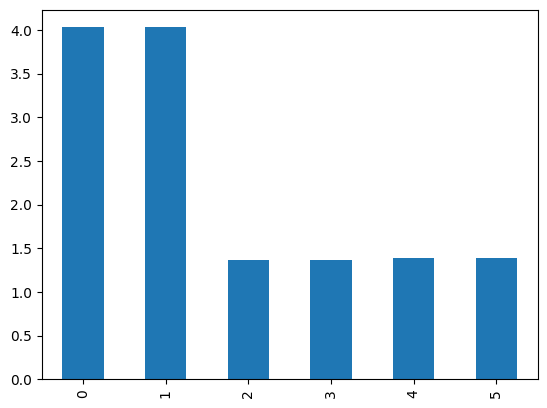

In [83]:
lift.plot(kind='bar')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

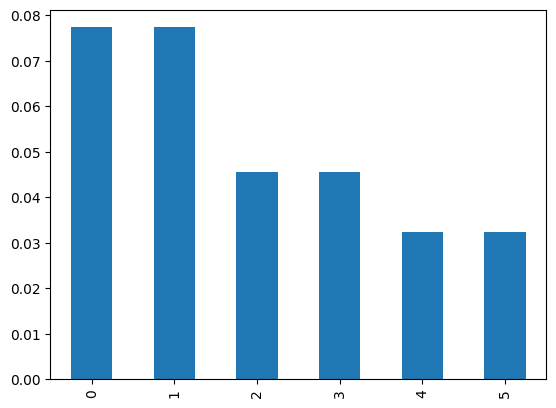

In [84]:
leverage.plot(kind='bar')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

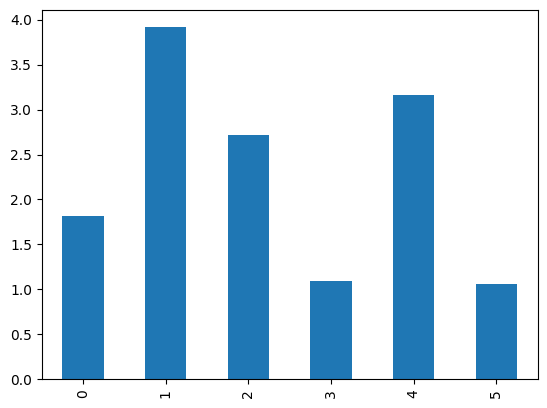

In [85]:
conviction.plot(kind='bar')
plt.show